In [1]:
# 1. Montar Google Drive para usar el dataset desde ahi
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Ruta Raiz del Dataset en mi Google Drive
ruta_raiz_dataset = "/content/drive/MyDrive/MIA/Dataset_origin"

## **Componentes del Pipeline**
| componente | Tipo de Transformación | ¿Qué Devuelve?|
|------------|------------------------|-----------|
|DataCleaner| Verificación de valores faltantes, outliers y limpieza| se puede acceder a self.missing y  self.outliers con las novedades encontradas |
|FeatureEngineer| Crea un dataset con features para análisis del dataset | self.df_ dataset con las features|
|YoloDatasetBalancer| Aplica balanceo sobre la subcarpeta train/ | Crea un nuevo dataset train balanceado en una nueva ruta sin modificar el original|

In [3]:
#Descargar los componentes con wget desde el repositorio
!wget https://raw.githubusercontent.com/ancantos99/proyectointegrador_ia_grupo8/refs/heads/main/src/utils/DataCleaner.py -O /content/DataCleaner.py
!wget https://raw.githubusercontent.com/ancantos99/proyectointegrador_ia_grupo8/refs/heads/main/src/utils/FeatureEngineer.py -O /content/FeatureEngineer.py
!wget https://raw.githubusercontent.com/ancantos99/proyectointegrador_ia_grupo8/refs/heads/main/src/utils/YoloDatasetBalancer.py -O /content/YoloDatasetBalancer.py


--2025-09-26 00:01:42--  https://raw.githubusercontent.com/ancantos99/proyectointegrador_ia_grupo8/refs/heads/main/src/utils/DataCleaner.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6695 (6.5K) [text/plain]
Saving to: ‘/content/DataCleaner.py’

/content/DataCleane 100%[===================>]   6.54K  --.-KB/s    in 0s      

2025-09-26 00:01:42 (85.2 MB/s) - ‘/content/DataCleaner.py’ saved [6695/6695]

--2025-09-26 00:01:42--  https://raw.githubusercontent.com/ancantos99/proyectointegrador_ia_grupo8/refs/heads/main/src/utils/FeatureEngineer.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443...

In [4]:
#para recargar clases, cuando hago cambios y las vuelvo a descargar
import importlib
import DataCleaner
import FeatureEngineer
import YoloDatasetBalancer
importlib.reload(DataCleaner)
importlib.reload(FeatureEngineer)
importlib.reload(YoloDatasetBalancer)

<module 'YoloDatasetBalancer' from '/content/YoloDatasetBalancer.py'>

## **Pipeline**

In [5]:
#Componentes propios
from DataCleaner import DataCleaner
from FeatureEngineer import FeatureEngineer
from YoloDatasetBalancer import YoloDatasetBalancer
####################################################################################
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE  # opcional si tienes clases desbalanceadas
import logging

# Configuración global
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    force=True
)

In [22]:
#Pipeline
pipeline = Pipeline([
    ("cleaner", DataCleaner(
        repo_path=ruta_raiz_dataset,
        nclasesmax=15,
        removerLabelsinvalidos=False,
        moverarchivosincompletos=False
    )),
    ("feature_eng", FeatureEngineer(
        repo_path=ruta_raiz_dataset,
        encoding_method="frequency",
        numeric_method="zscore",
        numeric_cols = ["area", "aspect_ratio", "center_dist"]
    )),
    ("balanceo", YoloDatasetBalancer(
        input_path="/content/drive/MyDrive/MIA/Dataset_origin",
        output_path="/content/drive/MyDrive/MIA/Dataset_balanceo",
        oversample=True,
        undersample=True,
        split="train",
        undersample_factor=2
    ))
])

2025-09-25 21:17:06,359 - DataCleaner - INFO - Se ha configurado un DataCleaner con repo_path=/content/drive/MyDrive/MIA/Dataset_origin 
nclasesmax=15 y 
removerLabelsinvalidos=False y 
moverarchivosincompletos=False
2025-09-25 21:17:06,360 - FeatureEngineer - INFO - Se ha configurado un FeatureEngineer con repo_path=/content/drive/MyDrive/MIA/Dataset_origin 
encoding_method=frequency y 
numeric_method=zscore y 
numeric_cols=['area', 'aspect_ratio', 'center_dist']
2025-09-25 21:17:06,361 - YoloDatasetBalancer - INFO - Se ha configurado un YoloDatasetBalancer con repo_path=/content/drive/MyDrive/MIA/Dataset_origin 
output_path=/content/drive/MyDrive/MIA/Dataset_balanceo y 
oversample=True y 
undersample=Truesplit=train y 
undersample_factor=2 y 



In [23]:
fitted_pipeline = pipeline.fit([0])
print("Pipeline ejecutado correctamente")


2025-09-25 21:17:32,717 - DataCleaner - INFO - Fit sen Subcarpet train/
2025-09-25 21:17:32,721 - DataCleaner - INFO - Inicia Verificación de Valores Faltantes en: /content/drive/MyDrive/MIA/Dataset_origin/train
2025-09-25 21:17:32,744 - DataCleaner - INFO - Inicia Verificación de Outliers en: /content/drive/MyDrive/MIA/Dataset_origin/train
2025-09-25 21:17:36,117 - DataCleaner - INFO - Fit sen Subcarpet val/
2025-09-25 21:17:36,120 - DataCleaner - INFO - Inicia Verificación de Valores Faltantes en: /content/drive/MyDrive/MIA/Dataset_origin/val
2025-09-25 21:17:36,126 - DataCleaner - INFO - Inicia Verificación de Outliers en: /content/drive/MyDrive/MIA/Dataset_origin/val
2025-09-25 21:17:36,343 - DataCleaner - INFO - Fit sen Subcarpet test/
2025-09-25 21:17:36,346 - DataCleaner - INFO - Inicia Verificación de Valores Faltantes en: /content/drive/MyDrive/MIA/Dataset_origin/test
2025-09-25 21:17:36,352 - DataCleaner - INFO - Inicia Verificación de Outliers en: /content/drive/MyDrive/MIA/

Pipeline ejecutado correctamente


In [24]:
cleaner_step = pipeline.named_steps['cleaner']
print("**Resumen de limpieza**")
print("- Faltantes:", cleaner_step.missing if cleaner_step.missing else "Ninguno")
print("- Outliers:", cleaner_step.outliers if cleaner_step.outliers else "Ninguno")

**Resumen de limpieza**
- Faltantes: Ninguno
- Outliers: Ninguno


In [25]:
feature_step = pipeline.named_steps['feature_eng']
print(feature_step.df_.head())

  subset  class         x         y         w         h      area  \
0  train      0  0.105729  0.044633  0.013542  0.042508  0.000576   
1  train      1  0.155554  0.044633  0.061108  0.046759  0.002857   
2  train      1  0.219629  0.044633  0.062874  0.046759  0.002940   
3  train      1  0.289099  0.044633  0.071899  0.046759  0.003362   
4  train      1  0.360954  0.044633  0.067643  0.046759  0.003163   

   aspect_ratio  center_dist  class_freq  area_zscore  aspect_ratio_zscore  \
0      0.318568     0.602336       19368    -0.201604            -0.274019   
1      1.306886     0.570966        6605    -0.128791            -0.156585   
2      1.344654     0.534759        6605    -0.126156            -0.152098   
3      1.537667     0.501835        6605    -0.112689            -0.129163   
4      1.446643     0.476122        6605    -0.119040            -0.139979   

   center_dist_zscore  
0            1.402184  
1            1.196993  
2            0.960164  
3            0.74480

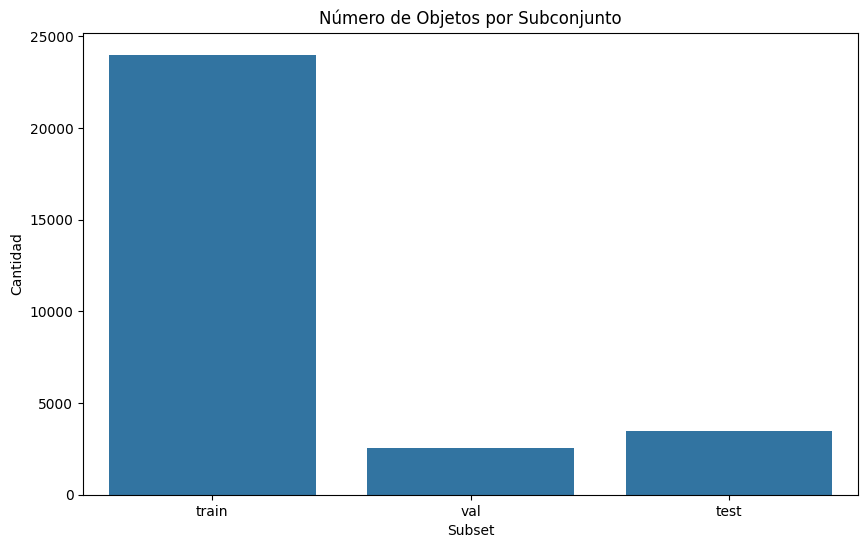

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
#objetos por subconjunto
plt.figure(figsize=(10,6))
sns.countplot(x="subset", data=feature_step.get_features())
plt.title("Número de Objetos por Subconjunto")
plt.xlabel("Subset")
plt.ylabel("Cantidad")
plt.show()

In [27]:
X_transformed = pipeline.transform([0])

2025-09-25 21:18:09,548 - DataCleaner - INFO - Transform DataCleaner completado
2025-09-25 21:18:09,549 - FeatureEngineer - INFO - Transform FeatureEngineer completado
2025-09-25 21:18:09,557 - YoloDatasetBalancer - INFO - Copiando dataset original...
2025-09-25 21:18:43,668 - YoloDatasetBalancer - INFO - Aplicando oversampling...


KeyboardInterrupt: 